# Regresión lineal con NumPy

En este notebook se ajusta una regresión lineal usando la ecuación normal, de acuerdo con lo visto en la unidad 4 - Introducción al Machine Learning, y se grafica el scatter plot de los datos junto con la línea de regresión.

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Datos

Se usa un dataset sintético que relaciona el tamaño de una casa en m² (X) con su precio en miles (y).

In [2]:
# Datos: tamaño en m^2 (X) y precio en miles (y)
X = np.array([50, 60, 70, 80, 90, 100, 110, 120])
y = np.array([150, 180, 195, 230, 260, 290, 325, 355])

print("Tamaños (m²):", X)
print("Precios (miles):", y)
print("Número de datos:", X.size)

Tamaños (m²): [ 50  60  70  80  90 100 110 120]
Precios (miles): [150 180 195 230 260 290 325 355]
Número de datos: 8


## 3. Scatter plot de los datos

Se grafican los datos para observar la relación entre el tamaño de la casa y su precio.

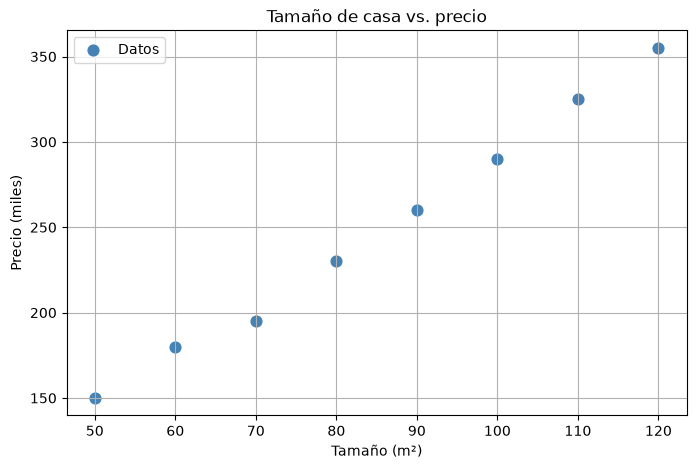

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", s=60, label="Datos")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (miles)")
plt.title("Tamaño de casa vs. precio")
plt.legend()
plt.grid(True)
plt.show()

## 4. Ajuste con la ecuación normal

La recta de regresión tiene la forma $y = \theta_0 + \theta_1 x$. Los parámetros se calculan con la ecuación normal:

$$\theta = (X^T X)^{-1} X^T y$$

Para incluir el intercepto $\theta_0$, se agrega una columna de unos a la matriz X.

In [4]:
m = X.size
X_b = np.c_[np.ones((m, 1)), X]   # columna de unos (theta_0)

print("Matriz X_b:")
print(X_b)

Matriz X_b:
[[  1.  50.]
 [  1.  60.]
 [  1.  70.]
 [  1.  80.]
 [  1.  90.]
 [  1. 100.]
 [  1. 110.]
 [  1. 120.]]


In [5]:
# Ecuación normal: theta = (X^T X)^-1 X^T y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Pendiente :", round(theta[1], 2))
print("Intercepto:", round(theta[0], 2))

Pendiente : 2.95
Intercepto: -2.32


## 5. Predicción

Se usa el modelo para estimar el precio de una casa de 95 m²:

$$\hat{y} = \theta_0 + \theta_1 \cdot 95$$

In [6]:
# Predicción para una casa de 95 m^2
precio = theta[0] + theta[1] * 95
print("Precio estimado:", round(precio, 2), "miles")

Precio estimado: 277.59 miles


## 6. Scatter plot con la línea de regresión

Se grafican los datos originales junto con la recta obtenida con la ecuación normal. También se marca la predicción para la casa de 95 m².

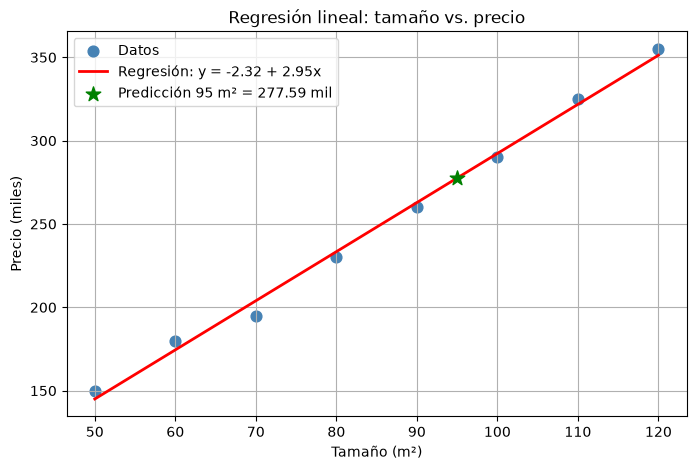

In [7]:
# Valores de la recta para cada tamaño
y_pred = X_b @ theta

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", s=60, label="Datos")
plt.plot(X, y_pred, color="red", linewidth=2,
         label=f"Regresión: y = {theta[0]:.2f} + {theta[1]:.2f}x")
plt.scatter(95, precio, color="green", s=120, marker="*", zorder=3,
            label=f"Predicción 95 m² = {precio:.2f} mil")

plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (miles)")
plt.title("Regresión lineal: tamaño vs. precio")
plt.legend()
plt.grid(True)
plt.show()

## 7. Conclusiones

- El scatter plot muestra una relación lineal positiva entre el tamaño de la casa y su precio: a mayor tamaño, mayor precio.
- Con la ecuación normal $\theta = (X^T X)^{-1} X^T y$ se obtuvo la recta $y = -2.32 + 2.95x$.
- La pendiente indica que por cada m² adicional, el precio aumenta aproximadamente 2.95 mil.
- El intercepto (-2.32) no tiene una interpretación real, ya que no existen casas de 0 m²; solo sirve para ubicar la recta.
- La línea de regresión pasa muy cerca de todos los puntos, por lo que el modelo describe bien los datos.
- Con el modelo se estimó que una casa de 95 m² costaría aproximadamente 277.59 mil, valor que se encuentra entre los precios de las casas de 90 m² y 100 m².
- La ecuación normal permite calcular los parámetros de forma directa, sin necesidad de un proceso iterativo.